# 15 · The Shifted Zero: Where BDM Sees Structure, and Where It Cannot

> **Revised 2026-10-02 (HID-v1, stage H0).** The scientific review in bitacora 33 §3 found
> six problems in the first version: character counts were read as if they were bits; the
> name *A* meant two different strings; the drop-tail scans compared objects of different
> coverage; a finite slope was described as a law; a CTM spread was read against an
> invariance "slack" that has no numerical value; and one statement about P3 was false.
> They are corrected below, and each corrected statement is checked by an executed cell.
> The original drop-policy measurements are kept, labelled **historical diagnostic**.

**The question.** Take eight 8-bit strings, $a_i = 1^{i}\,0\,1^{7-i}$ for $i = 0..7$: one zero
sliding across a line of ones. Written separately, a program for each one grows a little
longer as the zero moves inward. That small variation is what BDM/CTM reports too, and it is
the finer granularity that BDM is credited with over Shannon entropy, which is flat for these
strings. But an observer who sees *the shift* writes **one** program, with an index, that
generates every case.

**Names used throughout.** Positions are zero-based from the left.

| name | definition | bits |
|---|---|---|
| A64 | $a_0 a_1 \dots a_7$ | 64 |
| A72 | `11111111` + A64 | 72 |
| A24 | `11111111` $a_0 a_1$ (the scratch "A" of bitacora 32) | 24 |
| AX64 | `11111111` $a_0 \dots a_6$: cases 1..8 of the scratch indexing (the first 64 bits of A72, **not** A64) | 64 |
| AXM64 | the same eight cases in the order (8,1,6,7,2,4,3,5) | 64 |

**What we probe.**

| § | experiment | what it isolates |
|---|---|---|
| 1 | render the object | what the string actually is, before any measure |
| 2 | each case separately: program length, CTM, Shannon | per-block granularity |
| 3 | one program for all cases, and what it costs in bits | characters versus bits versus archives |
| 4 | sum of the parts versus the whole, at every block size | BDM's partition and its coverage |
| 5 | more zeros, from `11111111` to `00000000` | a finite slope, and why it is not a law |
| 6 | the same blocks in random order | does order register? |
| 7 | rotation: last bit moved to the front | does a one-bit relabelling register? |
| 8 | patterns of patterns: A24, AX64, AXM64, P1–P3 | repetition at a higher level |
| 9 | the period and the schema are different objects | why "period 9" is not "compact sumandos" |

**A rule we follow throughout.** $K$ is uncomputable, so on the Kolmogorov side we only
ever show **explicit programs that run and reproduce the string**, each an upper bound in a
stated language. A Python expression is measured in characters; it becomes a bit count only
under a stated encoding (UTF-8 here) and framing. The decodable binary archives of §3 are
measured in bits of a specified format. CTM values are in bits under the $D(5)$
Turing-machine reference. These units are not interchangeable, so we never set one against
another as a gap.

**Shannon appears only as a foil**, because the claim under test is phrased against it.
Under this project's rules it is never a complexity measure.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [ ]:
# The complexity measures live in ONE place: the repository's description-length owner.
_core = os.path.join(os.path.dirname(ROOT), "src")
for _p in (_core, ROOT):                       # ROOT first: a sibling repo ships a module "hierarchy"
    while _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("hierarchy", None)
import math, random, itertools, collections
from description_lengths import ctm_1d, bdm_1d, bdm_1d_partition
from hierarchy.wire import encode_literal
from hierarchy.infer import infer
from hierarchy.decode import decode_archive

def shannon_bits_per_symbol(s):
    """FOIL ONLY. Empirical Shannon entropy of the 0/1 frequencies -- not a complexity measure."""
    n = len(s); c = collections.Counter(s)
    return abs(-sum(v / n * math.log2(v / n) for v in c.values()))

def block_entropy(s, b):
    """FOIL ONLY. Shannon entropy (bits) of the distribution of aligned b-blocks."""
    blocks = [s[i:i + b] for i in range(0, len(s) - b + 1, b)]
    n = len(blocks); c = collections.Counter(blocks)
    return -sum(v / n * math.log2(v / n) for v in c.values())

def program_length(src, target):
    """Length (characters) of a Python expression that EVALUATES to target.
    Refuses a program that does not reproduce the string. Characters are not bits of a
    binary code: see section 3 for UTF-8 payload bits and actual archive bits."""
    out = eval(src, {"itertools": itertools})
    assert out == target, f"program does not reproduce the target: {src!r}"
    return len(src)

def show_bits(ax, strings, title, mark=None):
    """Render strings as rows of black (1) / white (0) cells -- the object itself."""
    M = np.array([[int(c) for c in s] for s in strings])
    ax.imshow(1 - M, cmap="gray", vmin=0, vmax=1, aspect="equal")
    ax.set_xticks(range(M.shape[1])); ax.set_yticks(range(M.shape[0]))
    ax.set_yticklabels(mark or strings, family="monospace", fontsize=8)
    ax.set_xticklabels(range(M.shape[1]), fontsize=7)
    ax.grid(False); ax.set_title(title)

def coverage(s, b, **kw):
    """Scored and dropped bits of one owner call, read from the partition it actually used."""
    d = bdm_1d_partition(s, block=b, **kw)
    return d["score"], d["covered_bits"], d["dropped_bits"]

ONES = "1" * 8
SHIFT = ["1" * i + "0" + "1" * (7 - i) for i in range(8)]   # zero at position i = 0..7
A64 = "".join(SHIFT)                                          # your string, 64 bits
A72 = ONES + A64                                              # with the all-ones anchor, 72 bits
print("A64 =", A64, len(A64), "bits")
print("A72 =", A72, len(A72), "bits")

# -----A64 -----
# 01111111
# 10111111
# 11011111
# 11101111
# 11110111
# 11111011
# 11111101
# 11111110

#-----A72--------
# 11111111
# 01111111
# 10111111
# 11011111
# 11101111
# 11110111
# 11111011
# 11111101
# 11111110

A64 = 0111111110111111110111111110111111110111111110111111110111111110 64 bits
A72 = 111111110111111110111111110111111110111111110111111110111111110111111110 72 bits


## 1 · The object, before any measure

Below are the eight cases, then A64 $= a_0 + a_1 + \dots + a_7$ wrapped into rows of **8**
bits and rows of **9** bits. Look at the right-hand panel before reading any number.

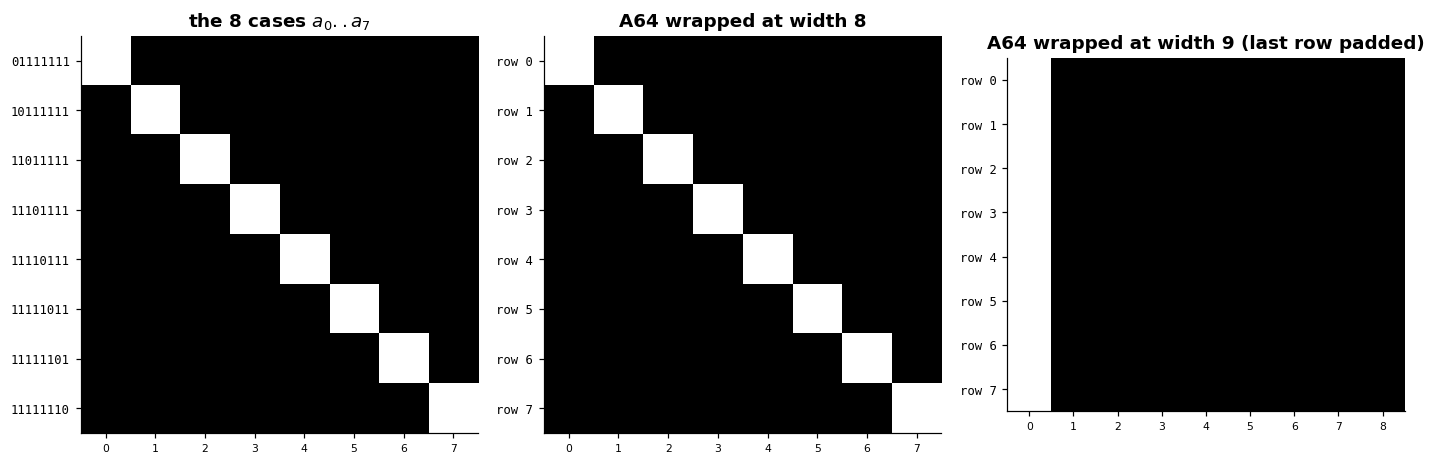

zero positions in A64: [0, 9, 18, 27, 36, 45, 54, 63]
gaps between zeros   : [9, 9, 9, 9, 9, 9, 9]


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
show_bits(ax[0], SHIFT, "the 8 cases $a_0..a_7$")
wrap = lambda s, w: [s[i:i + w].ljust(w, "1") for i in range(0, len(s), w)]
show_bits(ax[1], wrap(A64, 8), "A64 wrapped at width 8", mark=[f"row {r}" for r in range(8)])
w9 = wrap(A64, 9)
show_bits(ax[2], w9, "A64 wrapped at width 9 (last row padded)", mark=[f"row {r}" for r in range(len(w9))])
plt.tight_layout(); plt.show()
zeros = [i for i, c in enumerate(A64) if c == "0"]
print("zero positions in A64:", zeros)
print("gaps between zeros   :", np.diff(zeros).tolist())
assert zeros == list(range(0, 64, 9)) and A72 == ("1" * 8 + "0") * 8

**What the render shows.** At width 8 the zeros form a diagonal: the shift you designed.
At width 9 the diagonal collapses into **one vertical column**. The zeros sit at positions
$0, 9, 18, \dots, 63$, every gap is 9, and so

$$\mathrm{A64} = (0\,1^8)^7\,0 , \qquad \mathrm{A72} = 1^8 + \mathrm{A64} = (1^8\,0)^8 .$$

"Shift the zero one step per block" over blocks of 8 is, as a whole, a **period-9 string**.
At width 8 the shift is visible as a diagonal; at width 9 it disappears into plain
repetition. A partition of length 8 is the one choice that turns this repetition into eight
*different* blocks.

## 2 · Each case separately: program length, CTM, Shannon

First your nine one-off programs (`seq_11111111` …). We transcribe only the returned
expression, without `def` and docstring. Each one is checked by running it. Then CTM of each
8-bit string from the $D(5)$ table, and the Shannon foil.

In [4]:
USER_PROGS = {
    "11111111": 'f"{(1 << 8) - 1:08b}"',
    "01111111": 'f"{((1 << 8) - 1) >> 1:08b}"',
    "10111111": 'f"{(1 << 7) | (((1 << 8) - 1) >> 2):08b}"',
    "11011111": 'f"{(3 << 6) | (((1 << 8) - 1) >> 3):08b}"',
    "11101111": 'f"{(7 << 5) | (((1 << 8) - 1) >> 4):08b}"',
    "11110111": 'f"{(15 << 4) | (((1 << 8) - 1) >> 5):08b}"',
    "11111011": 'f"{(31 << 3) | (((1 << 8) - 1) >> 6):08b}"',
    "11111101": 'f"{(63 << 2) | (((1 << 8) - 1) >> 7):08b}"',
    "11111110": 'f"{((1 << 8) - 1) << 1 & 0xFF:08b}"',
}
cases = [ONES] + SHIFT
plen = [program_length(USER_PROGS[s], s) for s in cases]
ctm  = [ctm_1d(s) for s in cases]
H    = [shannon_bits_per_symbol(s) for s in cases]
print(f"{'string':>10} {'prog chars':>10} {'CTM bits':>9} {'Shannon b/sym':>13}")
for s, p, c, h in zip(cases, plen, ctm, H):
    print(f"{s:>10} {p:>10} {c:>9.3f} {h:>13.3f}")

    string prog chars  CTM bits Shannon b/sym
  11111111         21    18.527         0.000
  01111111         28    19.625         0.544
  10111111         41    19.923         0.544
  11011111         41    20.431         0.544
  11101111         41    19.914         0.544
  11110111         42    19.914         0.544
  11111011         42    20.431         0.544
  11111101         42    19.923         0.544
  11111110         35    19.625         0.544


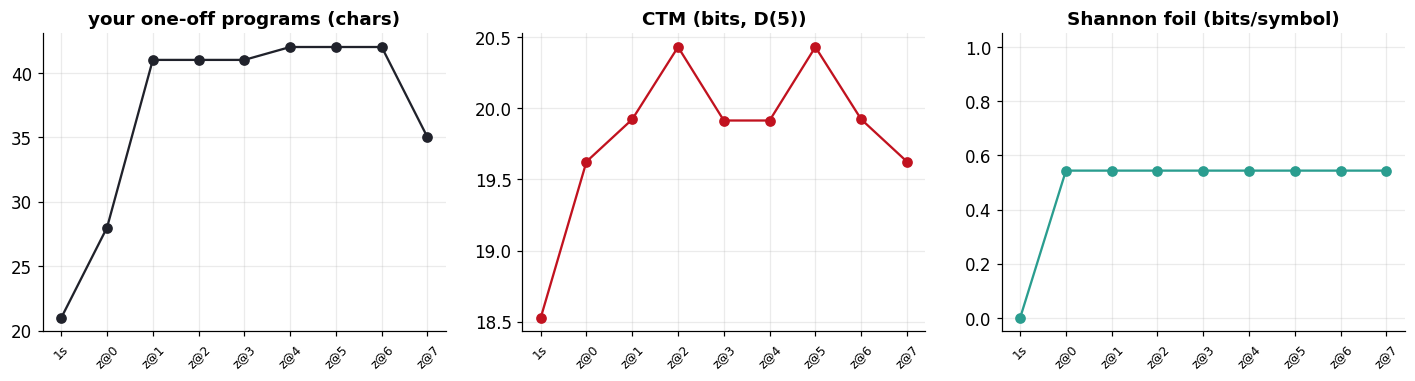

CTM spread over the 8 shifted cases: 0.805 bits (min 19.625, max 20.431)
CTM mirror-symmetric (a_i vs a_{7-i}): True


In [5]:
x = np.arange(len(cases)); lab = ["1s"] + [f"z@{i}" for i in range(8)]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(x, plen, "o-", color=INK); ax[0].set_title("your one-off programs (chars)")
ax[1].plot(x, ctm, "o-", color=HL);   ax[1].set_title("CTM (bits, D(5))")
ax[2].plot(x, H, "o-", color=OK);     ax[2].set_title("Shannon foil (bits/symbol)")
ax[2].set_ylim(-0.05, 1.05)
for a in ax: a.set_xticks(x); a.set_xticklabels(lab, rotation=45, fontsize=8)
plt.tight_layout(); plt.show()
spread = max(ctm[1:]) - min(ctm[1:])
print(f"CTM spread over the 8 shifted cases: {spread:.3f} bits (min {min(ctm[1:]):.3f}, max {max(ctm[1:]):.3f})")
print("CTM mirror-symmetric (a_i vs a_{7-i}):",
      all(abs(ctm_1d(SHIFT[i]) - ctm_1d(SHIFT[7 - i])) < 1e-12 for i in range(8)))

**Reading.** Your hand-drawn plot comes back, in CTM units: the all-ones string is the
cheapest, the zero at either end costs a little more, and the zero in the interior costs the
most, with a plateau there. Shannon is flat across all eight shifted cases, since each has
one zero and seven ones. So per block, CTM does show a granularity that Shannon lacks.

Two cautions keep the argument honest.

1. **The mirror symmetry is a property of the table, not a finding.** The $D(5)$ machine
   space is closed under reversal and complement, so $\mathrm{CTM}(a_i) =
   \mathrm{CTM}(a_{7-i})$ holds by construction. It is pinned as a test in the owner.
2. **The spread printed above is a table-dependent distinction, not an error bar.**
   *(Corrected.)* The first version said the spread lay "inside the invariance slack". The
   invariance theorem bounds the difference between two reference machines by a constant
   it does not evaluate, so it supplies **no numerical tolerance** against which this
   spread can be read, and the spread is not an estimated interval around true $K$. What
   the table shows is a distinction made by one reference machine, nothing more.
   Per-block granularity is in any case not where the argument bites; it bites where the
   blocks are *composed* (§3–§8).

## 3 · One program for every case — and what it costs in bits

Your indexed generator (`shift_zero_concat`) makes any case from an index. Below are four
Python expressions for **A64**, each checked by running it, measured three ways:

* **characters** of the expression (one language, Python source);
* **UTF-8 payload bits** of those characters, before any framing — what the text would
  occupy as a stored file;
* for comparison, the **actual decodable archives** of the HID-v1 format
  (`index-deconvolution/hierarchy`): the packed literal archive of A64, and the archive the
  bounded HID search finds for it. Archive bits include the 4-byte magic, codec byte, length
  fields and padding.

In [6]:
PROGS_A64 = {
    "literal (print the string)":  repr(A64),
    "your eight one-offs, joined":  " + ".join(USER_PROGS[s] for s in SHIFT),
    "indexed shift (your idea)":   "''.join('1'*i+'0'+'1'*(7-i) for i in range(8))",
    "period 9 (the render's idea)": "('0'+'1'*8)*7+'0'",
}
print(f"{'expression for A64':<30} {'chars':>5} {'UTF-8 bits':>10}")
for name, src in PROGS_A64.items():
    n = program_length(src, A64)
    print(f"{name:<30} {n:>5} {8 * len(src.encode('utf-8')):>10}   {src[:48]}{'...' if len(src) > 48 else ''}")
lit = encode_literal(A64)
hid = infer(A64)
assert decode_archive(hid.archive) == A64
print()
print(f"A64 itself                          : {len(A64)} bits")
print(f"packed literal archive (raw mode)   : {8 * len(lit)} bits  (64 data bits + 56 bits of envelope)")
print(f"HID-v1 search result                : {hid.archive_bits} bits, mode={hid.mode}")
p9 = "('0'+'1'*8)*7+'0'"
assert program_length(p9, A64) == 17 and 8 * len(p9.encode("utf-8")) == 136
p72 = "('1'*8+'0')*8"
print(f"\nA72 is generated by {p72!r}: {program_length(p72, A72)} characters "
      f"({8 * len(p72.encode('utf-8'))} UTF-8 bits); the 17-character expression outputs A64, not A72.")

expression for A64             chars UTF-8 bits
literal (print the string)        66        528   '01111111101111111101111111101111111101111111101...
your eight one-offs, joined      333       2664   f"{((1 << 8) - 1) >> 1:08b}" + f"{(1 << 7) | (((...
indexed shift (your idea)         46        368   ''.join('1'*i+'0'+'1'*(7-i) for i in range(8))
period 9 (the render's idea)      17        136   ('0'+'1'*8)*7+'0'

A64 itself                          : 64 bits
packed literal archive (raw mode)   : 120 bits  (64 data bits + 56 bits of envelope)
HID-v1 search result                : 120 bits, mode=literal

A72 is generated by "('1'*8+'0')*8": 13 characters (104 UTF-8 bits); the 17-character expression outputs A64, not A72.


**Reading (corrected).** The ranking of the four expressions is meaningful *within Python
source*: the joined one-offs inherit every case's private cost, the indexed generator
replaces eight programs with one, and the period-9 expression is shortest because it does
not shift anything, it repeats.

What the first version implied, and what does **not** follow: the 17-character period
expression occupies **136 UTF-8 payload bits** before any framing. That is shorter than the
*textual Python literal* of A64, but longer than the 64 bits of A64 itself. Characters of a
general-purpose language are not a compressed binary code, so these counts are not
bit-valued bounds on $K$ to be set against BDM bits.

A specified binary format changes the question. The HID-v1 archive above includes its whole
envelope; at 64 bits the envelope dominates and the search returns the literal mode, which is
the expected behaviour of a fixed format on a tiny input, not a failure. Whether such a
format is economical on *unseen* sequences is the subject of notebook 16 and its frozen
benchmark, not of this probe.

The generator is constant-sized only over this finite range of single-digit parameters. For
growing inputs the honest statement is $K(f(n,k)) \le K(n,k) + c_f$: the parameters, counts
and lengths must themselves be encoded.

## 4 · The sum of the parts against the whole, at every block size

BDM cuts the string into blocks, looks each distinct block up in the CTM table, and adds
$\log_2(\text{multiplicity})$ for repeats:
$\mathrm{BDM}(s) = \sum_{\text{distinct } b} \big[\mathrm{CTM}(b) + \log_2 n_b\big]$.

* With blocks of 8 aligned to your cases, every block of A64 is distinct, so
  $\mathrm{BDM}_8(\mathrm{A64}) = \sum_i \mathrm{CTM}(a_i)$ **exactly**.
* The informative experiment is to change the block length. The first version did this with
  pybdm's tail-dropping partition. **That scan is kept below as a historical diagnostic,
  with its coverage printed**, because a dropped tail changes the object being scored. Beside
  it are two full-coverage scans in which every bit is scored: the aligned **recursive**
  boundary (the remainder is scored as a shorter block) and **sliding** blocks with step 1.

sum of CTM(a_i), i=0..7        = 159.785 bits
BDM_8(A64) (aligned, whole)    = 159.785 bits   <- identical, by definition
control R72 = 001110101000101010101111101101101110100011010010110110010111100111001001


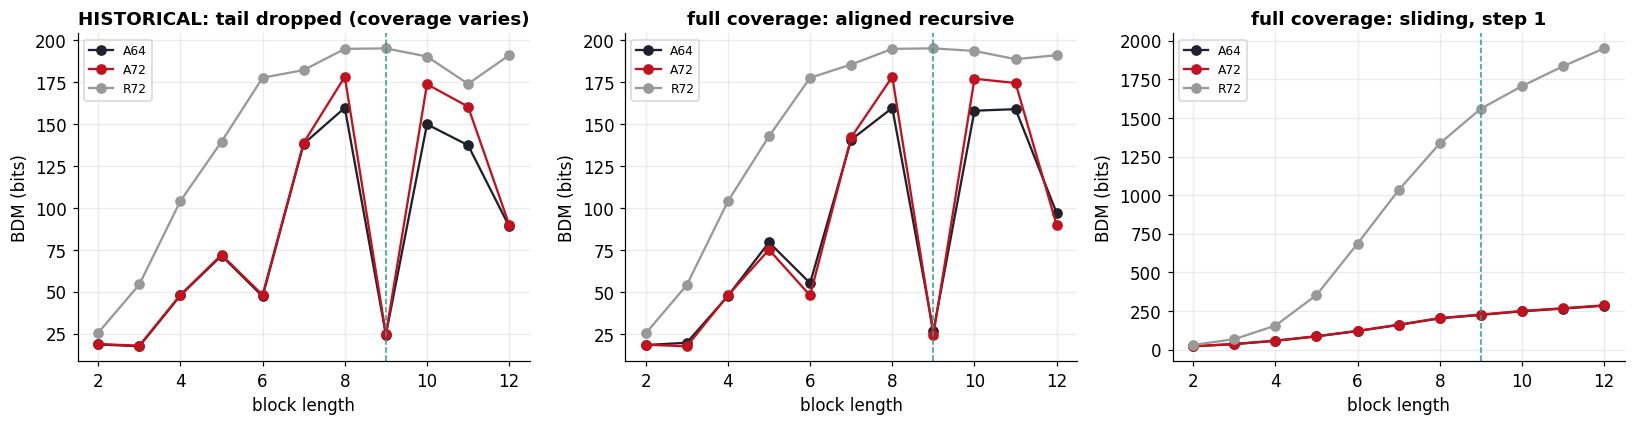

  b | A72 drop scored dropped  /R72 | A72 recursive  /R72 | A72 sliding  /R72
  2 |    18.79     72       0  0.74 |         18.79  0.74 |       21.60  0.73
  3 |    17.84     72       0  0.33 |         17.84  0.33 |       35.99  0.53
  4 |    48.14     72       0  0.46 |         48.14  0.46 |       57.56  0.37
  5 |    72.03     70       2  0.52 |         75.35  0.53 |       86.45  0.24
  6 |    48.10     72       0  0.27 |         48.10  0.27 |      121.01  0.18
  7 |   138.92     70       2  0.76 |        142.25  0.77 |      161.18  0.16
  8 |   178.31     72       0  0.91 |        178.31  0.91 |      203.96  0.15
  9 |    24.62     72       0  0.13 |         24.62  0.13 |      226.21  0.15
 10 |   173.86     70       2  0.91 |        177.18  0.91 |      249.81  0.15
 11 |   160.48     66       6  0.92 |        174.61  0.92 |      267.42  0.15
 12 |    90.03     72       0  0.47 |         90.03  0.47 |      286.20  0.15

raw minimum of BDM_b(A72) over b = 2..12 selects b = 3 (score 1

In [7]:
sum_parts = sum(ctm_1d(s) for s in SHIFT)
print(f"sum of CTM(a_i), i=0..7        = {sum_parts:.3f} bits")
print(f"BDM_8(A64) (aligned, whole)    = {bdm_1d(A64, block=8):.3f} bits   <- identical, by definition")
_r = random.Random(72)
R72 = "".join(_r.choice("01") for _ in range(72))   # control: a random 72-bit string, seed pinned
print("control R72 =", R72)
rows = []
for b in range(1, 13):
    for name, s in (("A64", A64), ("A72", A72), ("R72", R72)):
        drop, cov, dropped = coverage(s, b, remainder="drop")
        rec = bdm_1d(s, block=b, remainder="recursive")
        slide = bdm_1d(s, block=b, shift=1)
        rows.append(dict(name=name, b=b, drop=drop, covered=cov, dropped=dropped, recursive=rec, sliding=slide))
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, key, title in zip(ax, ("drop", "recursive", "sliding"),
                         ("HISTORICAL: tail dropped (coverage varies)", "full coverage: aligned recursive",
                          "full coverage: sliding, step 1")):
    for name, col in (("A64", INK), ("A72", HL), ("R72", "0.6")):
        bs = [r["b"] for r in rows if r["name"] == name and r["b"] >= 2]
        a.plot(bs, [r[key] for r in rows if r["name"] == name and r["b"] >= 2], "o-", color=col, label=name)
    a.axvline(9, color=OK, ls="--", lw=1); a.set(title=title, xlabel="block length", ylabel="BDM (bits)")
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()
ctl = {(r["b"]): r for r in rows if r["name"] == "R72"}
print(f"{'b':>3} | {'A72 drop':>8} {'scored':>6} {'dropped':>7} {'/R72':>5} | {'A72 recursive':>13} {'/R72':>5} | {'A72 sliding':>11} {'/R72':>5}")
for r in rows:
    if r["name"] == "A72" and r["b"] >= 2:
        c = ctl[r["b"]]
        print(f"{r['b']:>3} | {r['drop']:>8.2f} {r['covered']:>6} {r['dropped']:>7} {r['drop'] / c['drop']:>5.2f} | "
              f"{r['recursive']:>13.2f} {r['recursive'] / c['recursive']:>5.2f} | {r['sliding']:>11.2f} {r['sliding'] / c['sliding']:>5.2f}")
a72 = {r["b"]: r for r in rows if r["name"] == "A72"}
argmin_2_12 = min(range(2, 13), key=lambda b: a72[b]["drop"])
argmin_1_12 = min(range(1, 13), key=lambda b: a72[b]["drop"])
print(f"\nraw minimum of BDM_b(A72) over b = 2..12 selects b = {argmin_2_12} (score {a72[argmin_2_12]['drop']:.3f}); "
      f"over 1..12 it selects b = {argmin_1_12} (score {a72[argmin_1_12]['drop']:.3f})")
print("A72 coverage at b = 3, 9, 1:", [a72[b]["dropped"] for b in (3, 9, 1)], "bits dropped")
assert argmin_2_12 == 3 and argmin_1_12 == 1 and all(a72[b]["dropped"] == 0 for b in (1, 3, 9))

**Reading (corrected).** One string gets many values, and the spread is large: block 8 and
block 9 differ by about a factor of seven on A72 in the historical scan. At block 9 one block
is repeated eight times; at block 12, $\mathrm{lcm}(9,12)=36$, so every block occurs twice;
at block 8, $\mathrm{lcm}(9,8)=72$ and no block repeats, so A72 — which the 14-character
expression `('1'*8+'0')*8` generates — scores close to the random control. *(The first
version attributed this to the 17-character program; that program outputs A64, not A72.)*

**A raw minimum over block length does not find the period.** The printed scan shows it: over
$b = 2..12$ the minimum is at $b = 3$, not 9, and allowing $b = 1$ selects 1. All three
partitions cover every bit of A72, so this is not a tail artefact. Changing $b$ changes the
dictionary and how much ordering information is omitted, so the raw minimum does not compare
complete descriptions. Selecting a model needs complete code lengths; using BDM as a
discriminator needs calibration against matched controls with the whole selection rerun on
every control (notebook 16 does this).

**What BDM credits, stated precisely (narrowed).** The first version said repetition is "the
one regularity BDM rewards". That is too broad: CTM scores local structure inside each block
(§2). The defensible criticism is narrower: aligned BDM aggregates blocks as a **multiset**,
so relationships and order *between* blocks are not represented, and identical repetition is
credited only where the partition creates it. Known alternatives — overlapping (sliding)
blocks and recursive boundaries, shown in the right two panels — change the numbers; they
are discussed by the original BDM paper (Zenil et al., *Entropy* 20:605, 2018), so this probe
illustrates that discussion rather than discovering it.

## 5 · More zeros: from `11111111` to `00000000`

Two ways to generalise "one zero, shifted":

* **sliding run**: a run of $k$ zeros sliding through 8 positions, $1^{i}0^{k}1^{8-k-i}$,
  giving $9-k$ cases;
* **every placement**: all 8-bit strings with exactly $k$ zeros, giving $\binom{8}{k}$
  cases, concatenated in lexicographic order.

In [8]:
def fam_run(k):  return ["1" * i + "0" * k + "1" * (8 - k - i) for i in range(9 - k)] if k else [ONES]
def fam_comb(k): return ["".join("0" if j in c else "1" for j in range(8)) for c in itertools.combinations(range(8), k)]
GEN = {
    "run":  "''.join('1'*i+'0'*{k}+'1'*(8-{k}-i) for i in range(9-{k}))" ,
    "comb": "''.join(''.join('0'if j in c else'1'for j in range(8))for c in itertools.combinations(range(8),{k}))",
}
res = {}
for fam_name, fam in (("run", fam_run), ("comb", fam_comb)):
    for k in range(9):
        blocks = fam(k); s = "".join(blocks)
        gen = GEN[fam_name].format(k=k) if (fam_name == "comb" or k) else repr(ONES)
        res[fam_name, k] = dict(n=len(blocks), bits=len(s), bdm8=bdm_1d(s, block=8),
                                mean_ctm=np.mean([ctm_1d(b) for b in blocks]),
                                gen=program_length(gen, s), lit=program_length(repr(s), s))
print(f"{'fam':>4} {'k':>2} {'cases':>5} {'bits':>5} {'BDM_8':>8} {'mean CTM':>8} {'gen chars':>9} {'literal':>7}")
for (f, k), r in res.items():
    print(f"{f:>4} {k:>2} {r['n']:>5} {r['bits']:>5} {r['bdm8']:>8.1f} {r['mean_ctm']:>8.2f} {r['gen']:>9} {r['lit']:>7}")

 fam  k cases  bits    BDM_8 mean CTM gen chars literal
 run  0     1     8     18.5    18.53        10      10
 run  1     8    64    159.8    19.97        52      66
 run  2     7    56    146.9    20.98        52      58
 run  3     6    48    131.2    21.87        52      50
 run  4     5    40    110.5    22.09        52      42
 run  5     4    32     87.8    21.96        52      34
 run  6     3    24     62.8    20.94        52      26
 run  7     2    16     39.3    19.63        52      18
 run  8     1     8     18.5    18.53        52      10
comb  0     1     8     18.5    18.53        98      10
comb  1     8    64    159.8    19.97        98      66
comb  2    28   224    589.7    21.06        98     226
comb  3    56   448   1214.0    21.68        98     450
comb  4    70   560   1529.9    21.86        98     562
comb  5    56   448   1214.0    21.68        98     450
comb  6    28   224    589.7    21.06        98     226
comb  7     8    64    159.8    19.97        98 

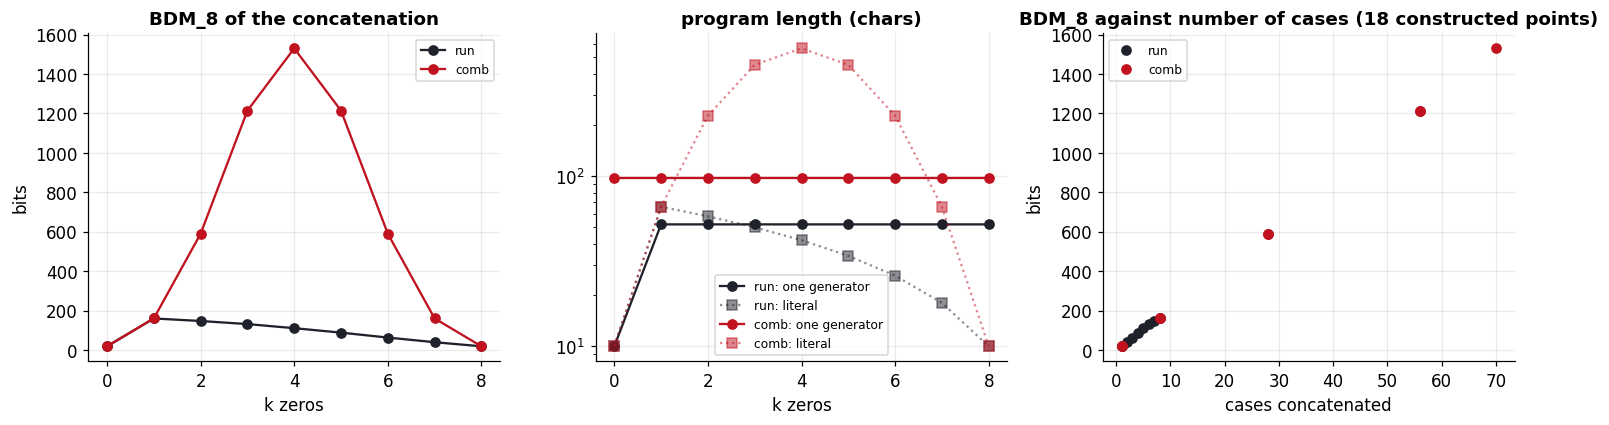

least-squares slope over these 18 constructed points: 21.78 bits per added case
comb family symmetric in k <-> 8-k: True
bound on BDM_8 for m =      10 complete blocks: C_8 + 256*log2(m) =     6344.3 bits (a literal of the same string has 80 bits)
bound on BDM_8 for m =     100 complete blocks: C_8 + 256*log2(m) =     7194.8 bits (a literal of the same string has 800 bits)
bound on BDM_8 for m =   10000 complete blocks: C_8 + 256*log2(m) =     8895.6 bits (a literal of the same string has 80000 bits)
bound on BDM_8 for m = 1000000 complete blocks: C_8 + 256*log2(m) =    10596.4 bits (a literal of the same string has 8000000 bits)


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for f, col in (("run", INK), ("comb", HL)):
    ks = range(9)
    ax[0].plot(ks, [res[f, k]["bdm8"] for k in ks], "o-", color=col, label=f)
    ax[1].plot(ks, [res[f, k]["gen"] for k in ks], "o-", color=col, label=f"{f}: one generator")
    ax[1].plot(ks, [res[f, k]["lit"] for k in ks], "s:", color=col, alpha=.5, label=f"{f}: literal")
    ax[2].plot([res[f, k]["n"] for k in ks], [res[f, k]["bdm8"] for k in ks], "o", color=col, label=f)
ax[0].set(title="BDM_8 of the concatenation", xlabel="k zeros", ylabel="bits")
ax[1].set(title="program length (chars)", xlabel="k zeros", yscale="log")
ax[2].set(title="BDM_8 against number of cases (18 constructed points)", xlabel="cases concatenated", ylabel="bits")
for a in ax: a.legend(fontsize=8)
plt.tight_layout(); plt.show()
n = np.array([res[f, k]["n"] for f in ("run", "comb") for k in range(9)])
v = np.array([res[f, k]["bdm8"] for f in ("run", "comb") for k in range(9)])
slope = np.polyfit(n, v, 1)[0]
print(f"least-squares slope over these 18 constructed points: {slope:.2f} bits per added case")
print("comb family symmetric in k <-> 8-k:",
      all(abs(res['comb', k]['bdm8'] - res['comb', 8 - k]['bdm8']) < 1e-9 for k in range(9)))
C8 = sum(ctm_1d(format(w, "08b")) for w in range(256))
for m in (10, 100, 10**4, 10**6):
    print(f"bound on BDM_8 for m = {m:>7} complete blocks: C_8 + 256*log2(m) = {C8 + 256 * math.log2(m):10.1f} bits "
          f"(a literal of the same string has {8 * m} bits)")

**Reading (corrected).**

* **On these constructed families, BDM_8 tracks the number of distinct cases.** Each new
  distinct 8-bit block adds its CTM. The printed slope summarises 18 constructed points with
  distinct blocks; they are not 18 independent observations of a scaling law, and there are
  only 256 distinct 8-bit words.
* **The finite slope is not an asymptotic law.** For a fixed block size $b$ and a finite CTM
  table, with $m$ complete blocks, $\mathrm{BDM}_b(x) \le C_b + 2^b \log_2 m$, where $C_b$
  is the sum of the table's CTM values: each multiplicity is at most $m$ and there are at
  most $2^b$ distinct words. Fixed-$b$ BDM therefore grows at most **logarithmically** in
  length, on fair random strings too. The last printed lines evaluate this bound; the first
  version's "BDM is linear in the number of cases" holds only in the finite constructed
  range.
* **The generator is constant only over a finite parameter range.** The $k=0$ sliding case
  is a different (literal) program, and for growing inputs the parameters themselves must be
  encoded, as in §3.
* For small families the literal is shorter than the generator: listing five cases or
  fewer is cheaper than describing the rule. That is the expected crossover.
* **Symmetry, and where it holds.** The *every placement* family is exactly symmetric in
  $k \leftrightarrow 8-k$ by complement invariance of the table. The *sliding run* family is
  not: its complement partner is a run of *ones* sliding through zeros.

## 6 · The same blocks in random order

Shuffle the nine cases of A72 and concatenate them. On the Kolmogorov side an arbitrary order
must be *specified*: a multiset of $m$ blocks with counts $n_j$ has $m!/\prod_j n_j!$
orderings, and an arbitrary one can be sent as a rank in that class — at most
$\lceil\log_2 9!\rceil$ bits for nine distinct cases — while a simple order may cost much
less. We draw 2000 shuffles (seed pinned) and score each at blocks 8, 9 and 12. Block 8 and 9
tile A72 exactly, so nothing is dropped there; at block 12 the historical drop policy is
used and its coverage printed.

block  8: ordered  178.31 | shuffles min  178.31 median  178.31 max  178.31 | share of shuffles <= ordered 1.0000 | dropped 0
block  9: ordered   24.62 | shuffles min   47.14 median  137.33 max  179.55 | share of shuffles <= ordered 0.0000 | dropped 0


block 12: ordered   90.03 | shuffles min   87.58 median  171.54 max  175.06 | share of shuffles <= ordered 0.0015 | dropped 0


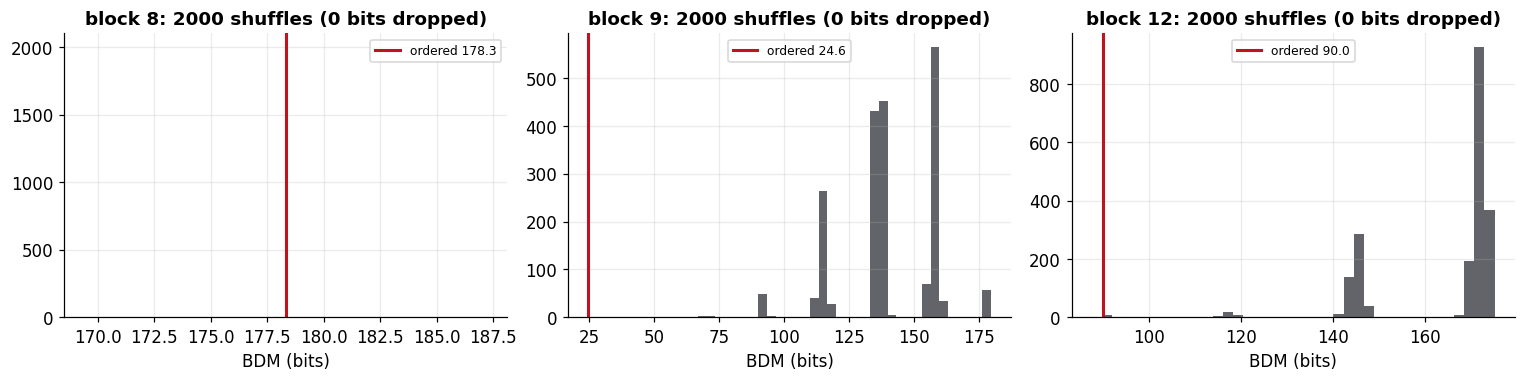

log2(9!) = 18.47 bits
block-entropy foil, block 8: ordered 3.170, every shuffle 3.170


In [10]:
rng = random.Random(15)
blocks9 = [ONES] + SHIFT
ordered = "".join(blocks9)
assert ordered == A72
shuffles = []
for _ in range(2000):
    p = blocks9[:]; rng.shuffle(p); shuffles.append("".join(p))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, b in zip(ax, (8, 9, 12)):
    vals = np.array([bdm_1d(s, block=b, remainder="drop") for s in shuffles])
    o, cov, dropped = coverage(ordered, b, remainder="drop")
    a.hist(vals, bins=40 if np.ptp(vals) > 1e-6 else 1, color=INK, alpha=.7); a.axvline(o, color=HL, lw=2, label=f"ordered {o:.1f}")
    a.set(title=f"block {b}: 2000 shuffles ({dropped} bits dropped)", xlabel="BDM (bits)"); a.legend(fontsize=8)
    print(f"block {b:>2}: ordered {o:7.2f} | shuffles min {vals.min():7.2f} median {np.median(vals):7.2f} "
          f"max {vals.max():7.2f} | share of shuffles <= ordered {np.mean(vals <= o + 1e-9):.4f} | dropped {dropped}")
plt.tight_layout(); plt.show()
print(f"log2(9!) = {math.log2(math.factorial(9)):.2f} bits")
print(f"block-entropy foil, block 8: ordered {block_entropy(ordered, 8):.3f}, every shuffle {block_entropy(shuffles[0], 8):.3f}")

**Reading.**

* **Block 8 (aligned to the cases): order does not register at all.** All 2000 shuffles get
  *exactly* the ordered value. Aligned BDM is a function of the multiset of blocks, and in
  this respect it is the same as the block-entropy foil.
* **Blocks 9 and 12: the ordered string is among the lowest.** Once the partition cuts
  *across* the cases, the ordered string's repetition becomes repeated blocks; shuffling
  breaks it and BDM rises. This is the correct direction, but it is bought by the choice of
  block length, as in §4.

The order information reaches aligned BDM only through **coincidences between the partition
and the generator**.

## 7 · Rotation: move the last bit to the front

A *specified* one-position rotation changes $K$ by at most a fixed program constant. An
**arbitrary** rotation must also transmit its amount: at most $\lceil\log_2 n\rceil + O(1)$
bits when $n$ is available from the decoded object, and the implementation constant cannot
simply be dropped. We do your experiment on A64 and A72, sweep every rotation amount, and
repeat it for one shuffled string as a control.

A64: rotated by 1 -> blocks of 8: ['00111111', '11011111', '11101111', '11110111', '11111011', '11111101', '11111110', '11111111']
      BDM_8 before 159.785   after 159.505
A72: rotated by 1 -> blocks of 8: ['01111111', '10111111', '11011111', '11101111', '11110111', '11111011', '11111101', '11111110', '11111111']
      BDM_8 before 178.312   after 178.312
BDM_8  A72 ordered   over 72 rotations: min  178.31 max  178.31 spread   0.00 bits (dropped tail: 0 bits)
BDM_8  A64           over 64 rotations: min  158.87 max  159.79 spread   0.92 bits (dropped tail: 0 bits)
BDM_8  A72 shuffled  over 72 rotations: min  124.63 max  178.31 spread  53.69 bits (dropped tail: 0 bits)
BDM_12 A72 ordered   over 72 rotations: min   90.03 max   90.33 spread   0.30 bits (dropped tail: 0 bits)
BDM_12 A64           over 64 rotations: min   89.03 max  148.68 spread  59.65 bits (dropped tail: 4 bits)
BDM_12 A72 shuffled  over 72 rotations: min  169.21 max  172.05 spread   2.84 bits (dropped tail: 0 bits)


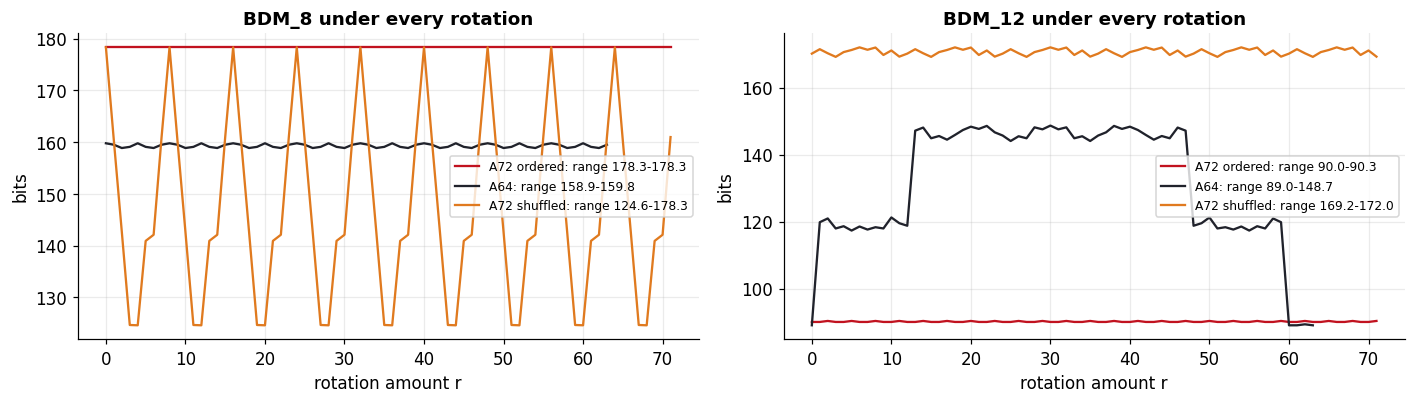

an arbitrary rotation index for n = 64 costs at most ceil(log2 64) = 6 bits + O(1)


In [11]:
rot = lambda s, r: s[-r:] + s[:-r] if r else s
for name, s in (("A64", A64), ("A72", A72)):
    r1 = rot(s, 1)
    print(f"{name}: rotated by 1 -> blocks of 8: {[r1[i:i+8] for i in range(0, len(r1), 8)]}")
    print(f"      BDM_8 before {bdm_1d(s, block=8):.3f}   after {bdm_1d(r1, block=8):.3f}")
shuf = shuffles[0]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for a, b in zip(ax, (8, 12)):
    for name, s, col in (("A72 ordered", A72, HL), ("A64", A64, INK), ("A72 shuffled", shuf, BAD)):
        vals = [bdm_1d(rot(s, r), block=b, remainder="drop") for r in range(len(s))]
        a.plot(vals, color=col, label=f"{name}: range {min(vals):.1f}-{max(vals):.1f}")
        print(f"BDM_{b:<2} {name:<13} over {len(s)} rotations: min {min(vals):7.2f} max {max(vals):7.2f} "
              f"spread {max(vals) - min(vals):6.2f} bits (dropped tail: {len(s) % b} bits)")
    a.set(title=f"BDM_{b} under every rotation", xlabel="rotation amount r", ylabel="bits")
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("an arbitrary rotation index for n = 64 costs at most ceil(log2 64) =", math.ceil(math.log2(64)), "bits + O(1)")

**Reading.**

* **A72: every rotation leaves BDM_8 unchanged.** This is not robustness: a rotation of a
  period-9 string is again period-9, and its 8-blocks are the same multiset.
* **A64: rotation by one is not invisible, but it is small at block 8**, and much larger at
  block 12, where 64 is not a multiple of 12 and the historical scan drops a tail.
* **The shuffled control** spreads widely at block 8: without the period, every shift of the
  seams lands on new blocks.

For $K$, the rotated strings differ from the original by a rotation index, at most
$\lceil\log_2 n\rceil$ bits plus a constant.

## 8 · Patterns of patterns: A24, AX64, AXM64, P1, P2, P3

These are the page-19 constructions, previously only in a scratch appendix of bitacora 32
(where "A" meant A24, a different object from A64). Cases follow `shift_zero_concat`: case 1
is all ones and case $j+1$ has its zero at position $j$. P1 = A24·A24, P2 = A24·AX64·AXM64,
P3 = AXM64·AXM64·AXM64. For each block length the table prints the full length, the bits
scored and dropped by the **historical drop policy**, the block count and distinct blocks,
the repeated blocks, and the full-coverage recursive score.

In [12]:
CASES = [ONES] + SHIFT
cat = lambda idx: "".join(CASES[j - 1] for j in idx)
A24, AX64, AXM64 = cat([1, 2, 3]), cat(range(1, 9)), cat([8, 1, 6, 7, 2, 4, 3, 5])
assert AX64 == A72[:64] and AX64 != A64
PATTERNS = {"A24": A24, "AX64": AX64, "AXM64": AXM64, "P1": A24 * 2, "P2": A24 + AX64 + AXM64, "P3": AXM64 * 3}
pp = {}
print(f"{'object':<6} {'len':>4} {'b':>3} {'drop BDM':>9} {'scored':>6} {'dropped':>7} {'blocks':>6} {'distinct':>8} "
      f"{'recursive BDM':>13}  repeated blocks (multiplicity)")
for name, s in PATTERNS.items():
    for b in (8, 9, 12):
        drop, cov, dropped = coverage(s, b, remainder="drop")
        blocks = [s[i:i + b] for i in range(0, cov, b)]
        cnt = collections.Counter(blocks)
        rep = {k: v for k, v in sorted(cnt.items()) if v > 1}
        rec = bdm_1d(s, block=b, remainder="recursive")
        pp[name, b] = dict(drop=drop, cov=cov, dropped=dropped, blocks=len(blocks), distinct=len(cnt), rec=rec)
        print(f"{name:<6} {len(s):>4} {b:>3} {drop:>9.1f} {cov:>6} {dropped:>7} {len(blocks):>6} {len(cnt):>8} {rec:>13.1f}  "
              + (", ".join(f"{k}x{v}" for k, v in rep.items()) or "-"))
assert pp["P3", 12]["blocks"] == 16 and pp["P3", 12]["distinct"] == 15
assert pp["A24", 9]["dropped"] == 6 and pp["AX64", 12]["dropped"] == 4 and pp["AXM64", 12]["dropped"] == 4
assert pp["P2", 12]["dropped"] == 8 and pp["P3", 12]["dropped"] == 0
assert abs(pp["AX64", 8]["drop"] - pp["AXM64", 8]["drop"]) < 1e-9
for name in ("AX64", "AXM64"):
    r = infer(PATTERNS[name]); assert decode_archive(r.archive) == PATTERNS[name]
    print(f"HID-v1 archive for {name}: {r.archive_bits} bits (literal archive {r.literal_bits} bits), "
          f"archive bytes differ: order is transmitted")

object  len   b  drop BDM scored dropped blocks distinct recursive BDM  repeated blocks (multiplicity)
A24      24   8      58.1     24       0      3        3          58.1  -
A24      24   9      22.6     18       6      2        1          36.0  111111110x2
A24      24  12      56.3     24       0      2        2          56.3  -
AX64     64   8     158.7     64       0      8        8         158.7  -
AX64     64   9      24.4     63       1      7        1          26.9  111111110x7
AX64     64  12      89.0     60       4      5        3          97.3  111110111111x2, 111111110111x2
AXM64    64   8     158.7     64       0      8        8         158.7  -
AXM64    64   9     135.0     63       1      7        6         137.5  111111011x2
AXM64    64  12     117.4     60       4      5        4         125.4  111111011111x2
P1       48   8      61.1     48       0      6        3          61.1  01111111x2, 10111111x2, 11111111x2
P1       48   9      67.1     45       3      5     

**Reading (corrected).**

* **Coverage differs between rows of the historical scan.** A24 at block 9 scores 18 of 24
  bits (25 % dropped); AX64 and AXM64 at block 12 score 60 of 64; P2 at block 12 scores 144
  of 152; P3 at block 12 scores all 192. The first version's P3/AXM ratio at block 12 therefore
  mixed a partition effect with different coverage. The recursive column scores every bit.
* **P3 at block 12 has 16 blocks and 15 distinct ones; one block occurs twice.** The first
  version's statement that no block repeats was false. $\mathrm{lcm}(64, 12) = 192$ explains
  when the alignment recurs, not the absence of accidental repeated contents.
* **BDM_8 cannot tell AX64 from AXM64** (equal scores, asserted above). A decodable archive
  must transmit the order; the two HID archives differ.
* At block 8, P3's three repeats of each block are credited as $\log_2 3$ per distinct block;
  a description that names "three copies of AXM64" pays for the repetition once. This is the
  level argument, now on an executed cell.

## 9 · The period and the schema are different objects

The zeros of A64 sit at addresses $0, 9, 18, \dots, 63$, which in six-bit binary read
`000000, 001001, …, 111111` — the form `abcabc`. Sumandos are the fillings of a schema's
**own don't-care coordinates** (GLOSSARY §1d). Every ordinary wildcard cube with more than one
point contains two addresses at Hamming distance one. The cell checks that no two zero
addresses are Hamming neighbours, so a cube cover of this zero support **in the original six
coordinates needs eight singleton cubes** — no stars at all, despite the simple period.

In [13]:
zs = [i for i, c in enumerate(A64) if c == "0"]
print("zero addresses (6-bit):", [f"{z:06b}" for z in zs])
edges = [(x, y) for x in zs for y in zs if x < y and bin(x ^ y).count("1") == 1]
print("Hamming-one pairs among them:", edges)
assert not edges

zero addresses (6-bit): ['000000', '001001', '010010', '011011', '100100', '101101', '110110', '111111']
Hamming-one pairs among them: []


**Reading.** "Recover period 9" is therefore not automatically "recover compact sumandos".
This does not make the string incompressible: its complementary support, an arithmetic
progression of step 9, relations between coordinates, or a transformation may all be
economical — but each has to be defined and **charged** in a decodable code. Notebook 16
builds such a code (HID-v1), with arithmetic progressions and schemata as separate,
explicitly transmitted rule types, and tests it on held-out sequences.

## What the probe supports, and what it does not

**Supported, by the cells above:**

1. Per case, CTM makes distinctions Shannon does not (§2); the spread is a property of one
   reference table, not an error interval.
2. BDM's value for a fixed string depends strongly on the block length and the boundary
   policy (§4); its low values occur where the partition matches the period, and a raw
   minimum over block length does not identify the period.
3. Aligned BDM aggregates blocks as a multiset: relationships and order between blocks are
   not represented (§6, §8).
4. Characters of a Python expression are not bits of a binary code (§3).

**Not supported. Do not claim these:**

* "BDM is no better than Shannon", "BDM rewards only repetition", or "BDM is wrong about
  $K$".
* A linear growth law for fixed-$b$ BDM (§5 gives the logarithmic bound).
* Any absolute comparison of CTM bits with program characters.
* That letting the data pick $b$ by raw minimum would find the generator (§4).

The next experiment is not another BDM example: it is a specified, decodable code whose
inference is frozen before it meets new sequences — notebook 16.